In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


load dataset and perform initial inspection

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.shape

(1000, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Descriptive statistics

In [10]:
cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

print("Mean:")
print(cols.mean())

print("\nMedian:")
print(cols.median())

print("\nMode:")
print(cols.mode().iloc[0])

print("\nStandard Deviation:")
print(cols.std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


Time series analysis

In [14]:
df['Date'] = pd.to_datetime(df['Date'])


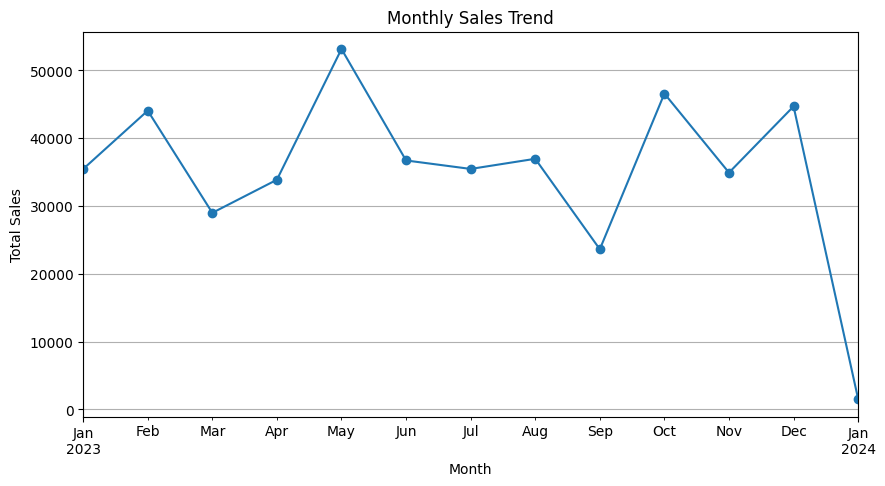

In [16]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Monthly sales show variation across months with some month may generating the highest sales while january 2024 generating the least 

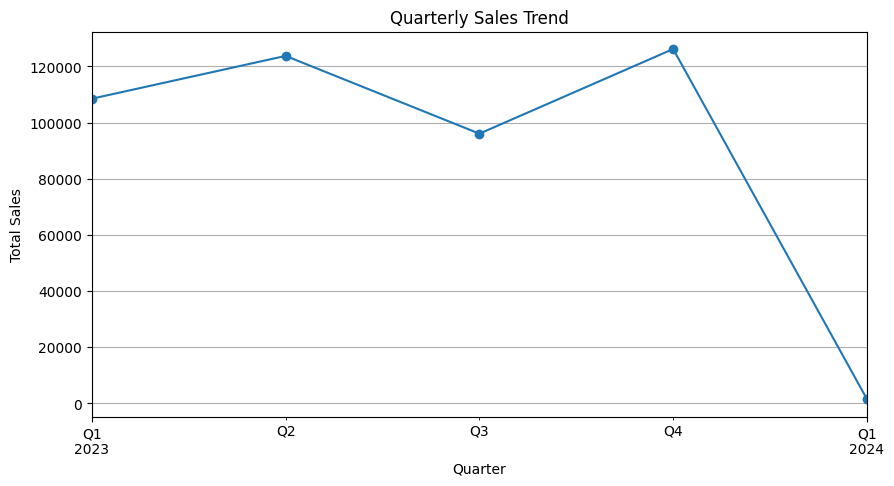

In [17]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Quarterly sales indicate overall revenue changes across larger time periods. The highest-performing quarter is Q4

customer demographics analysis 

In [18]:
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['<18', '18-30', '31-40', '41-50', '51-60', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_groups = df['Age Group'].value_counts().sort_index()
print(age_groups)

Age Group
<18       21
18-30    252
31-40    193
41-50    221
51-60    220
60+       93
Name: count, dtype: int64


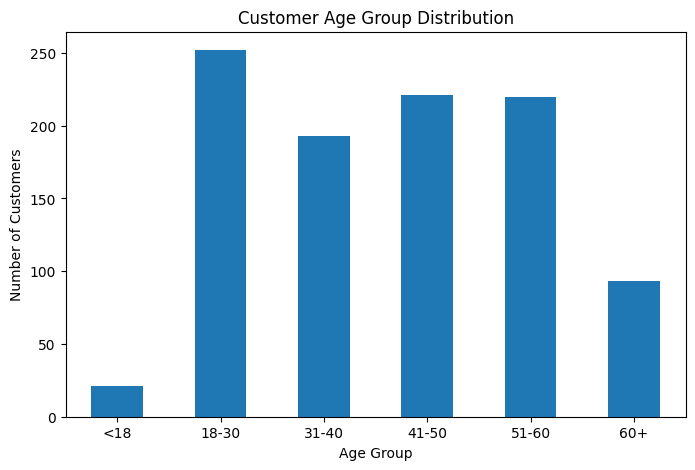

In [19]:
plt.figure(figsize=(8,5))
age_groups.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

the age group from 18-30 has highest customers. This group can be targeted with personalized offers and marketing campaigns.

Gender
Female    510
Male      490
Name: count, dtype: int64


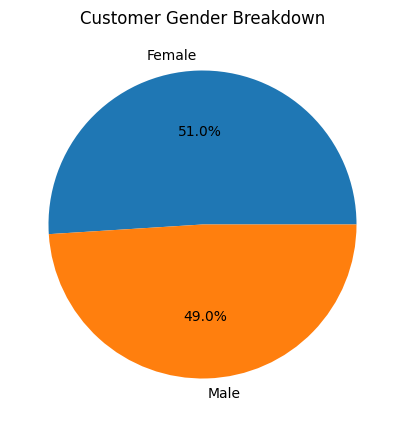

In [20]:
gender_count = df['Gender'].value_counts()
print(gender_count)
plt.figure(figsize=(6,5))
gender_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Gender Breakdown')
plt.ylabel('')
plt.show()

there are more female customers than male 

Product analysis


In [24]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
print(top_products.head(10))

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


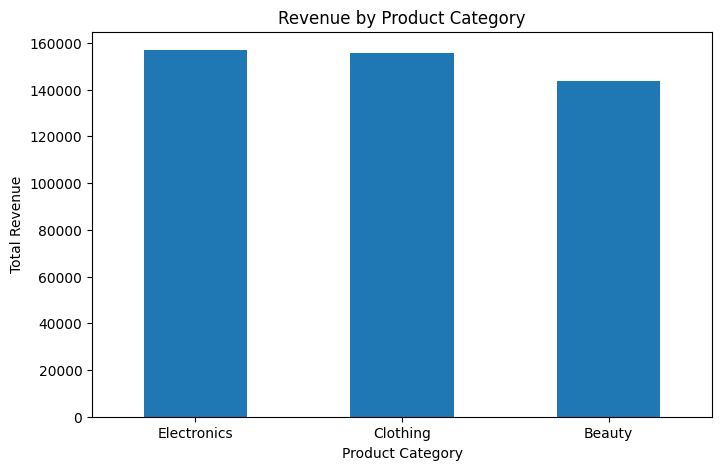

In [26]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

Electronics generate considerably more revenue than others. this should be prioritized for inventory and promotions, while weaker categories can be reviewed for improvement.

heatmap


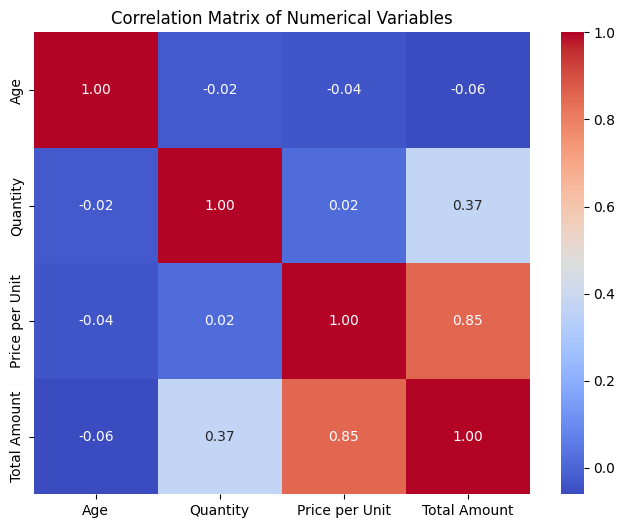

In [28]:
import seaborn as sns
num_cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
correlation = num_cols.corr()
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

The correlation matrix shows the relationships between numerical variables. In particular, the relationship between Quantity, Price per Unit, and Total Amount can help explain the factors contributing to transaction revenue.

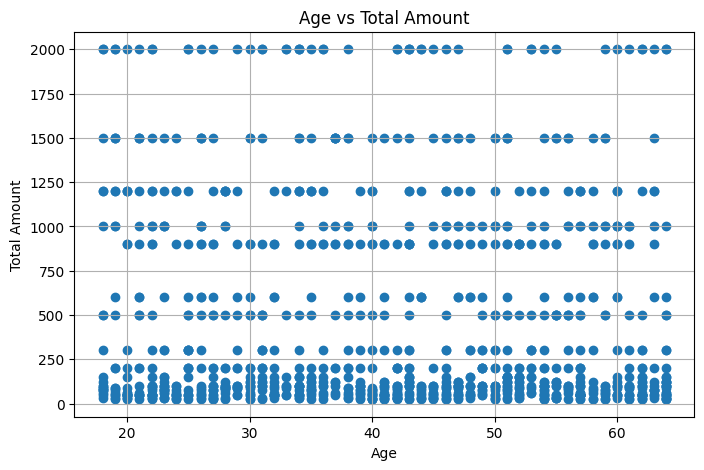

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Age'], df['Total Amount'])

plt.title('Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

The scatter plot helps identify whether customer age is associated with spending. The distribution of points can reveal whether certain age groups tend to have higher transaction amounts.

# Conclusion

The analysis provides insights into sales trends, customer demographics, product performance, and relationships between numerical variables.

### Business Recommendations

1. Target the largest customer age group: Focus marketing campaigns, discounts, and personalized offers on the age group with the highest customer representation.that is age group 18-30 

2. Focus on high-revenue product categories(Electronics): Maintain sufficient inventory for the categories generating the most revenue and promote these products during high-demand periods.

3. Use seasonal sales trends: Plan promotions and inventory based on monthly and quarterly sales patterns, especially during periods of lower sales to improve overall revenue.

4. Improve weaker-performing categories: Review categories with lower sales or revenue and consider targeted discounts, better product positioning, or promotional campaigns to increase demand.